In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.feature_selection import VarianceThreshold, SelectFromModel, RFE
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                             confusion_matrix, classification_report,
                             RocCurveDisplay)
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.stats import mannwhitneyu
from xgboost import XGBClassifier
from worcgist.load_data import load_data

warnings.filterwarnings('ignore')

Number of samples : 246
Number of columns : 494
Total missing values: 0

--- Data Info ---
<class 'pandas.DataFrame'>
Index: 246 entries, GIST-001_0 to GIST-246_0
Columns: 494 entries, label to PREDICT_original_phasef_phasesym_entropy_WL3_N5
dtypes: float64(468), int64(25), str(1)
memory usage: 951.3+ KB

Label distribution:
label
GIST        125
non-GIST    121
Name: count, dtype: int64


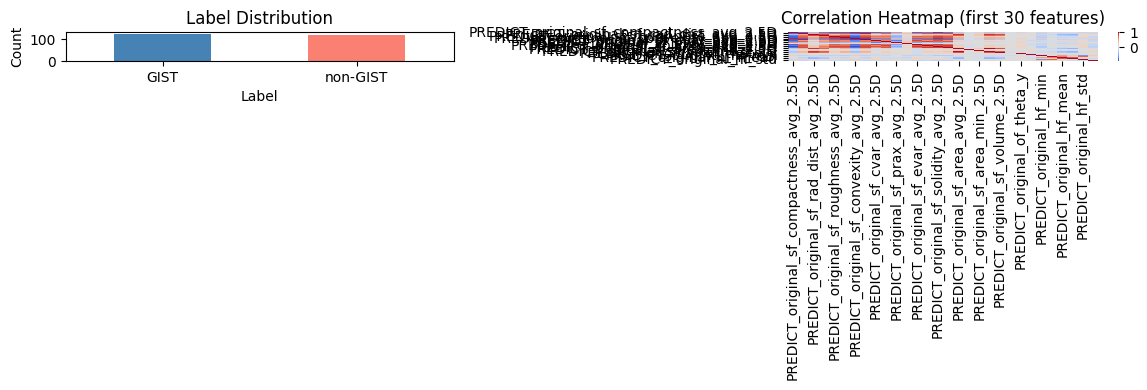


Label encoding: {'GIST': np.int64(0), 'non-GIST': np.int64(1)}

Train size: 196 | Test size: 50

Features before variance thresholding : 493
Features after  variance thresholding : 352
Features after  correlation filtering : 181

--- Fitting feature selectors ---
Mann-Whitney  features selected : 76
LASSO         features selected : 36
RFE           features selected : 20

--- Training models ---
  [Mann-Whitney U] + [Logistic Regression] ... AUC=0.504  F1=0.500
  [Mann-Whitney U] + [Random Forest] ... AUC=0.577  F1=0.571
  [Mann-Whitney U] + [SVM] ... 

KeyboardInterrupt: 

In [7]:

# =============================================================================
# 1. DATA LOADING AND INSPECTION
# =============================================================================
# ---- Replace this block with your worcgist loader if needed ----
data = load_data()
      # drop the sample-ID column
# ----------------------------------------------------------------

print(f'Number of samples : {len(data)}')
print(f'Number of columns : {len(data.columns)}')
print(f'Total missing values: {data.isnull().sum().sum()}')
print('\n--- Data Info ---')
data.info()
print(f'\nLabel distribution:\n{data["label"].value_counts()}')

# Label distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data['label'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('Label Distribution')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Correlation heatmap (first 30 numeric features)
features_subset = data.select_dtypes(include=['float64', 'int64']).iloc[:, :30]
sns.heatmap(features_subset.corr(), cmap='coolwarm', annot=False, ax=axes[1])
axes[1].set_title('Correlation Heatmap (first 30 features)')
plt.tight_layout()
plt.savefig('data_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# 2. PREPROCESSING
# =============================================================================
label_encoder = LabelEncoder()
data['label'] = label_encoder.fit_transform(data['label'])
print(f'\nLabel encoding: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}')

X = data.drop(columns=['label'])
y = data['label']

# --- Train / test split (stratified 80/20) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f'\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

# --- Variance thresholding ---
vt = VarianceThreshold(threshold=0.01)
X_train_vt = pd.DataFrame(vt.fit_transform(X_train),
                           columns=X_train.columns[vt.get_support()])
X_test_vt  = pd.DataFrame(vt.transform(X_test),
                           columns=X_train.columns[vt.get_support()])

# --- Robust scaling ---
scaler = RobustScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train_vt), columns=X_train_vt.columns)
X_test_sc  = pd.DataFrame(scaler.transform(X_test_vt),      columns=X_test_vt.columns)

# --- Correlation filtering (|r| > 0.90) ---
corr_matrix = X_train_sc.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.90)]
X_train_final = X_train_sc.drop(columns=to_drop)
X_test_final  = X_test_sc.drop(columns=to_drop)

print(f'\nFeatures before variance thresholding : {X_train.shape[1]}')
print(f'Features after  variance thresholding : {X_train_vt.shape[1]}')
print(f'Features after  correlation filtering : {X_train_final.shape[1]}')

# =============================================================================
# 3. FEATURE SELECTION METHODS
# =============================================================================

# ---- 3a. Mann-Whitney U (univariate, non-parametric) ----
class MannWhitneySelector(BaseEstimator, TransformerMixin):
    """Select features whose Mann-Whitney U p-value < alpha."""
    def __init__(self, alpha=0.05):
        self.alpha = alpha

    def fit(self, X, y):
        X = np.array(X)
        self.selected_mask_ = np.array([
            mannwhitneyu(X[y == 0, i], X[y == 1, i], alternative='two-sided').pvalue < self.alpha
            for i in range(X.shape[1])
        ])
        return self

    def transform(self, X):
        return np.array(X)[:, self.selected_mask_]

    def get_support(self):
        return self.selected_mask_


# ---- 3b. LASSO (L1 logistic regression via SelectFromModel) ----
def lasso_selector(X_train, y_train, C=0.1):
    lasso = LogisticRegression(penalty='l1', solver='liblinear', C=C,
                               random_state=42, max_iter=1000)
    selector = SelectFromModel(lasso, prefit=False)
    selector.fit(X_train, y_train)
    return selector


# ---- 3c. RFE with Logistic Regression ----
def rfe_selector(X_train, y_train, n_features=20):
    estimator = LogisticRegression(solver='liblinear', random_state=42,
                                   max_iter=1000)
    selector = RFE(estimator, n_features_to_select=n_features, step=10)
    selector.fit(X_train, y_train)
    return selector


# =============================================================================
# 4. CLASSIFIERS WITH HYPERPARAMETER GRIDS
# =============================================================================
cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

CLASSIFIERS = {
    'Logistic Regression': (
        LogisticRegression(solver='liblinear', random_state=42, max_iter=1000),
        {'C': [0.01, 0.1, 1, 10]}
    ),
    'Random Forest': (
        RandomForestClassifier(random_state=42),
        {'n_estimators': [100, 200], 'max_depth': [None, 5, 10]}
    ),
    'SVM': (
        SVC(probability=True, random_state=42),
        {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
    ),
    'XGBoost': (
        XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0),
        {'n_estimators': [100, 200], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1]}
    ),
}

# =============================================================================
# 5. EVALUATION HELPER
# =============================================================================
def evaluate(clf, X_tr, y_tr, X_te, y_te, param_grid):
    """Tune with inner CV, return test metrics dict."""
    grid = GridSearchCV(clf, param_grid, cv=cv_inner,
                        scoring='roc_auc', n_jobs=-1)
    grid.fit(X_tr, y_tr)
    best = grid.best_estimator_
    y_pred  = best.predict(X_te)
    y_proba = best.predict_proba(X_te)[:, 1]
    return {
        'best_params' : grid.best_params_,
        'cv_auc'      : round(grid.best_score_, 4),
        'test_auc'    : round(roc_auc_score(y_te, y_proba), 4),
        'test_acc'    : round(accuracy_score(y_te, y_pred), 4),
        'test_f1'     : round(f1_score(y_te, y_pred), 4),
        'estimator'   : best,
        'y_pred'      : y_pred,
        'y_proba'     : y_proba,
    }

# =============================================================================
# 6. MAIN EXPERIMENT LOOP
# =============================================================================
X_tr, y_tr = X_train_final.values, y_train.values
X_te, y_te = X_test_final.values,  y_test.values

# ---- Build feature selection variants ----
print('\n--- Fitting feature selectors ---')

mw_sel   = MannWhitneySelector(alpha=0.05).fit(X_tr, y_tr)
lasso_sel = lasso_selector(X_tr, y_tr, C=0.1)
rfe_sel   = rfe_selector(X_tr, y_tr, n_features=20)

X_tr_mw    = mw_sel.transform(X_tr)
X_te_mw    = mw_sel.transform(X_te)
X_tr_lasso = lasso_sel.transform(X_tr)
X_te_lasso = lasso_sel.transform(X_te)
X_tr_rfe   = rfe_sel.transform(X_tr)
X_te_rfe   = rfe_sel.transform(X_te)

print(f'Mann-Whitney  features selected : {X_tr_mw.shape[1]}')
print(f'LASSO         features selected : {X_tr_lasso.shape[1]}')
print(f'RFE           features selected : {X_tr_rfe.shape[1]}')

FEATURE_SETS = {
    'Mann-Whitney U' : (X_tr_mw,    X_te_mw),
    'LASSO'          : (X_tr_lasso, X_te_lasso),
    'RFE'            : (X_tr_rfe,   X_te_rfe),
}

# ---- Run all combinations ----
results = []
trained_models = {}   # store for ROC curves

print('\n--- Training models ---')
for fs_name, (X_tr_fs, X_te_fs) in FEATURE_SETS.items():
    for clf_name, (clf, grid) in CLASSIFIERS.items():
        print(f'  [{fs_name}] + [{clf_name}] ...', end=' ', flush=True)
        metrics = evaluate(clf, X_tr_fs, y_tr, X_te_fs, y_te, grid)
        results.append({
            'Feature Selection' : fs_name,
            'Classifier'        : clf_name,
            'CV AUC'            : metrics['cv_auc'],
            'Test AUC'          : metrics['test_auc'],
            'Test Accuracy'     : metrics['test_acc'],
            'Test F1'           : metrics['test_f1'],
            'Best Params'       : metrics['best_params'],
        })
        trained_models[(fs_name, clf_name)] = metrics
        print(f"AUC={metrics['test_auc']:.3f}  F1={metrics['test_f1']:.3f}")

results_df = pd.DataFrame(results).sort_values('Test AUC', ascending=False)
print('\n=== RESULTS (sorted by Test AUC) ===')
print(results_df[['Feature Selection', 'Classifier', 'CV AUC',
                   'Test AUC', 'Test Accuracy', 'Test F1']].to_string(index=False))

# =============================================================================
# 7. VISUALISATIONS
# =============================================================================

# ---- 7a. Heatmaps: AUC per FS x Classifier ----
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
metrics_to_plot = [('Test AUC', 'Blues'), ('Test Accuracy', 'Greens'), ('Test F1', 'Oranges')]

for ax, (metric, cmap) in zip(axes, metrics_to_plot):
    pivot = results_df.pivot(index='Classifier', columns='Feature Selection', values=metric)
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap=cmap, vmin=0.5, vmax=1.0,
                linewidths=0.5, ax=ax)
    ax.set_title(metric)
    ax.set_ylabel('')

plt.suptitle('Performance Across Feature Selection × Classifier', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('performance_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- 7b. Grouped bar chart – Test AUC ----
fig, ax = plt.subplots(figsize=(12, 5))
pivot_auc = results_df.pivot(index='Classifier', columns='Feature Selection', values='Test AUC')
pivot_auc.plot(kind='bar', ax=ax, width=0.7, edgecolor='white')
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Random baseline')
ax.set_title('Test AUC by Classifier and Feature Selection Method')
ax.set_xlabel('')
ax.set_ylabel('AUC')
ax.tick_params(axis='x', rotation=15)
ax.legend(title='Feature Selection', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('auc_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- 7c. ROC curves for best model per feature-selection method ----
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, fs_name in zip(axes, FEATURE_SETS.keys()):
    # find best classifier for this FS method
    subset = results_df[results_df['Feature Selection'] == fs_name]
    best_clf_name = subset.loc[subset['Test AUC'].idxmax(), 'Classifier']

    for clf_name in CLASSIFIERS:
        m = trained_models[(fs_name, clf_name)]
        _, X_te_fs = FEATURE_SETS[fs_name]
        RocCurveDisplay.from_predictions(
            y_te, m['y_proba'],
            name=f"{clf_name} (AUC={m['test_auc']:.2f})",
            ax=ax
        )
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    ax.set_title(f'ROC — {fs_name}')
    ax.legend(fontsize=7, loc='lower right')

plt.suptitle('ROC Curves per Feature Selection Method', fontsize=13)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- 7d. Confusion matrix of the overall best model ----
best_row = results_df.iloc[0]
best_key = (best_row['Feature Selection'], best_row['Classifier'])
best_metrics = trained_models[best_key]

cm = confusion_matrix(y_te, best_metrics['y_pred'])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_, ax=ax)
ax.set_title(f"Confusion Matrix\n{best_row['Feature Selection']} + {best_row['Classifier']}")
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.savefig('best_model_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n--- Classification report: {best_key} ---')
print(classification_report(y_te, best_metrics['y_pred'],
                             target_names=label_encoder.classes_))

# =============================================================================
# 8. SAVE RESULTS TABLE
# =============================================================================
results_df.to_csv('model_results.csv', index=False)
print('\nResults saved to model_results.csv')
print('Figures saved: data_overview.png, performance_heatmaps.png,')
print('               auc_bar_chart.png, roc_curves.png,')
print('               best_model_confusion_matrix.png')